In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 79.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pp
import seaborn as sns
!pip install scorecardpy --quiet
import scorecardpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
from category_encoders.woe import WOEEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
dagshub.init(repo_owner='kgord23', repo_name='ML_hw_02_IEEE-CIS', mlflow=True)
mlflow.set_experiment("XGBoost_Training")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a6b7cdac-345f-4fbc-be85-36747fec38b6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a91f20666525431a54513dd0fe21bea9e73f92fd9fa600d17ac2334b4879cedf




Accessing as kgord23

Initialized MLflow to track repo "kgord23/ML_hw_02_IEEE-CIS"

Repository kgord23/ML_hw_02_IEEE-CIS initialized!

<Experiment: artifact_location='mlflow-artifacts:/ed0174ee2afa4254aa3eb4db52265f25', creation_time=1777975051247, experiment_id='4', last_update_time=1777975051247, lifecycle_stage='active', name='XGBoost_Training', tags={}, trace_location=None, workspace='default'>

In [4]:
train_transaction= pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')


In [5]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [6]:
X=train.drop(columns='isFraud')
Y=train['isFraud']

X_train, X_val, Y_train, Y_val= train_test_split(X,Y, test_size=0.2, random_state=42)
X_train_raw = X_train.copy()
X_val_raw = X_val.copy()


<h1>Cleaning</h1>

In [7]:
class NULLDropperThreshold(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold=threshold
        
    def fit(self, X, y=None):
        missing_frac=X.isna().mean()
        self.cols_to_drop=missing_frac[missing_frac>self.threshold].index.tolist()
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

In [85]:
missing_percent = X_train.isna().mean()* 100
missing_percent.sort_values(ascending=False)
missing_percent.describe()
missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

In [86]:
threshold=0.90
cols_to_drop = missing_frac[missing_frac>threshold].index
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [41]:
with mlflow.start_run(run_name="XGBoost_Cleaning"):
    mlflow.log_param("null_threshold", 0.90)
    mlflow.log_metric("remaining_features", X_train.shape[1])
    mlflow.log_metric("remaining_rows", X_train.shape[0])

🏃 View run XGBoost_Cleaning at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/d6c4d2523ae741b4af4cb18d6f20ec30
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4


<h1>Feature Engineering</h1>

In [8]:
class NewColsAdd(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.email_freq=X['P_emaildomain'].value_counts()
        self.card_freqs={}
        for col in ['card1', 'card2', 'addr1']:
            self.card_freqs[col]=X[col].value_counts()
        X_tmp=X.copy()
        X_tmp['card_det']=X_tmp['card1'].astype(str) + '_' + X_tmp['card2'].astype(str) + '_' + X_tmp['addr1'].astype(str)
        self.card_det_freq=X_tmp['card_det'].value_counts()
        return self

    def transform(self, X):
        X=X.copy()
        X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
        X['Transaction_hour'] = ((X['TransactionDT'] / 3600) % 24).astype(int)
        X['Transaction_day'] = ((X['TransactionDT'] / (3600 * 24)) % 7).astype(int)
        X['P_emaildomain_freq'] = X['P_emaildomain'].map(self.email_freq)
        X['card_det']=X['card1'].astype(str)+ '_' + X['card2'].astype(str)+'_'+X['addr1'].astype(str)

        for col in ['card1', 'card2', 'addr1']:
            X[col + '_freq'] = X[col].map(self.card_freqs[col])
        X['card_det_freq'] = X['card_det'].map(self.card_det_freq)
        return X

        

In [87]:
X_train['TransactionAmt_log']= np.log1p(X_train['TransactionAmt'])
X_val['TransactionAmt_log']=np.log1p(X_val['TransactionAmt'])

email_freq=X_train['P_emaildomain'].value_counts()
X_train['P_emaildomain_freq'] = X_train['P_emaildomain'].map(email_freq)
X_val['P_emaildomain_freq']=X_val['P_emaildomain'].map(email_freq)


X_train['Transaction_day'] = ((X_train['TransactionDT']/(3600*24))%7).astype(int)
X_train['Transaction_hour'] = ((X_train['TransactionDT']/3600)%24).astype(int)
X_val['Transaction_day'] = ((X_val['TransactionDT']/(3600*24))%7).astype(int)
X_val['Transaction_hour'] = ((X_val['TransactionDT']/3600)%24).astype(int)

X_train['card_det'] = X_train['card1'].astype(str)+'_' + X_train['card2'].astype(str)+'_' + X_train['addr1'].astype(str)
X_val['card_det'] = X_val['card1'].astype(str)+'_' + X_val['card2'].astype(str)+'_' + X_val['addr1'].astype(str)
for col in ['card1', 'card2', 'addr1', 'card_det']:
    card_freq=X_train[col].value_counts()
    X_train[col+'_freq']=X_train[col].map(card_freq)
    X_val[col+'_freq']=X_val[col].map(card_freq)

In [73]:
#used this for enable_categorical=True in XGBClassifier
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_val[cat_cols] = X_val[cat_cols].astype('category')

In [88]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"amount_of_cat_cols: {len(cat_cols)}")
print(f"cols: {cat_cols}")

amount_of_cat_cols: 30
cols: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'card_det']


In [16]:
class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

        self.woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29','id_30', 'id_31', 'id_33',  'id_34', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']
    def fit(self, X, y=None):
        self.woe_cols_pr=[c for c in self.woe_cols if c in X.columns]
        self.ohe_cols_pr=[c for c in self.ohe_cols if c in X.columns]

        self.woe=WOEEncoder(cols=self.woe_cols_pr)
        self.woe.fit(X[self.woe_cols_pr],y)

        X_tmp = pd.get_dummies(X, columns=self.ohe_cols_pr)
        self.feature_names = X_tmp.columns 
        return self

    def transform(self, X):
        X=X.copy()
        for col in self.woe_cols_pr:
            if col not in X.columns:
                X[col] = 0
        X[self.woe_cols_pr]=self.woe.transform(X[self.woe_cols_pr])
        X=pd.get_dummies(X, columns=self.ohe_cols_pr)
        X = X.reindex(columns=self.feature_names, fill_value=0)
        return X
        

In [89]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29','id_30', 'id_31', 'id_33',  'id_34', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

after WOE : 430
afte OHE: 451


In [32]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6',  'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

after WOE : 234
afte OHE: 254


In [12]:
from category_encoders import WOEEncoder
ohe_cols = ['card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 
            'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'ProductCD']

woe_cols = ['P_emaildomain', 'R_emaildomain', 'id_12', 'id_15', 
            'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 
            'id_37', 'id_38', 'DeviceInfo', 'card_det']

woe=WOEEncoder(cols=woe_cols)
X_train[woe_cols]=woe.fit_transform(X_train[woe_cols], Y_train)
X_val[woe_cols]=woe.transform(X_val[woe_cols])
print(f"after WOE : {X_train.shape[1]}")


X_train=pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns = ohe_cols)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
print(f"afte OHE: {X_train.shape[1]}")

after WOE : 368
afte OHE: 389


In [45]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):
    mlflow.log_metric("total_features", X_train.shape[1])
    mlflow.log_param("ohe_cols", ", ".join(ohe_cols))
    mlflow.log_param("woe_cols", ", ".join(woe_cols))

🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/7f25e3d47c59419b84b9919085ceec74
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4


<h1>Feature Selection</h1>

In [20]:
corr_matrix = X_train.corr().abs()
corr_with_target = X_train.copy()
corr_with_target['isFraud'] = Y_train.values
corr_with_target = corr_with_target.corr()['isFraud'].drop('isFraud')
threshold=0.85
to_drop=set()
for i in range (len(corr_matrix.columns)):
    for j in range(i +1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j])>threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            if abs (corr_with_target[col_i])<abs(corr_with_target[col_j]):
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)
print(f"to_delete: {len(to_drop)}")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_val=X_val.drop(columns=list(to_drop))
print(f"left cols: {X_train.shape[1]}")

to_delete: 213
{'V95', 'V279', 'C8', 'V224', 'V29', 'V193', 'C10', 'V225', 'id_38', 'V178', 'V219', 'ProductCD_W', 'V318', 'V272', 'V86', 'R_emaildomain', 'M2_T', 'V135', 'ProductCD_C', 'V229', 'V81', 'V237', 'V307', 'V246', 'V298', 'V217', 'V218', 'V274', 'V119', 'V275', 'V34', 'addr2', 'V44', 'V82', 'V137', 'V59', 'V97', 'V105', 'V15', 'M4_M2', 'V16', 'V182', 'V90', 'V259', 'V243', 'V93', 'V131', 'C7', 'id_35', 'TransactionDT', 'V64', 'V207', 'id_31', 'V133', 'V11', 'V13', 'V267', 'V188', 'V92', 'V196', 'V215', 'V242', 'V302', 'V31', 'V17', 'V206', 'V255', 'V252', 'V200', 'V230', 'V245', 'V54', 'V313', 'V32', 'V103', 'V70', 'C1', 'V113', 'V69', 'V254', 'V278', 'V4', 'V58', 'V126', 'V296', 'V129', 'V19', 'V295', 'V311', 'V14', 'V79', 'V181', 'V127', 'C6', 'V106', 'V194', 'V33', 'V306', 'V39', 'V265', 'V203', 'V212', 'V65', 'V172', 'V202', 'C5', 'V57', 'V167', 'V221', 'V177', 'V183', 'V214', 'id_36', 'id_17', 'V303', 'V308', 'V280', 'id_37', 'V27', 'V100', 'card4_visa', 'V73', 'V96', '

In [21]:
with mlflow.start_run(run_name="XBoost_Selection"):
    mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_metric("left columns",X_train.shape[1])

🏃 View run XBoost_Selection at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/c8e18eb02ad24c84bf6f28d6b217dd56
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4


<h1>Training</h1>

In [90]:
xgb = XGBClassifier(
    #enable_categorical=True, 
    #tree_method='hist', 
    n_estimators=250,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=30,  
    n_jobs=-1,
    random_state=42,
    eval_metric='auc'
)
xgb.fit(X_train, Y_train)
Y_pred_proba_train=xgb.predict_proba(X_train)[:,1]
Y_pred_proba_val=xgb.predict_proba(X_val)[:,1]
Y_pred_val = xgb.predict(X_val)

roc_auc_train=roc_auc_score(Y_train, Y_pred_proba_train)
roc_auc_val=roc_auc_score(Y_val, Y_pred_proba_val)
overfitting=roc_auc_train - roc_auc_val
print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"diff:            {roc_auc_train - roc_auc_val:.4f}")
print(classification_report(Y_val, Y_pred_val))

Train ROC-AUC:      0.9891
Validation ROC-AUC: 0.9589
diff:            0.0302
              precision    recall  f1-score   support

           0       0.99      0.94      0.97    113866
           1       0.35      0.85      0.49      4242

    accuracy                           0.94    118108
   macro avg       0.67      0.90      0.73    118108
weighted avg       0.97      0.94      0.95    118108



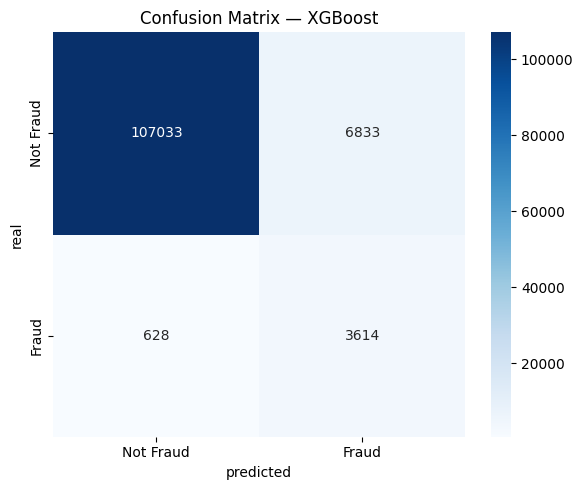

In [91]:
cm = confusion_matrix(Y_val, Y_pred_val)
tn, fp, fn, tp = cm.ravel()
pp.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
pp.title('Confusion Matrix — XGBoost')
pp.ylabel('real')
pp.xlabel('predicted')
pp.tight_layout()
pp.savefig('XG_confusion_matrix.png')
pp.show()

In [76]:
with mlflow.start_run(run_name="XGBoost_Training"):
    mlflow.set_tag("description", "with no correlation filter")
    #mlflow.set_tag("encoding", "enable_categorical=True")
    mlflow.log_param("null_threshold", 0.90)
    #mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_param("n_estimators", 250)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", 30)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("precision", precision_score(Y_val, Y_pred_val))
    mlflow.log_metric("recall", recall_score(Y_val, Y_pred_val))
    mlflow.log_metric("f1", f1_score(Y_val, Y_pred_val))
    
    tn, fp, fn, tp = confusion_matrix(Y_val, Y_pred_val).ravel()
    mlflow.log_metric("true_positive", tp)
    mlflow.log_metric("false_negative", fn)
    
    mlflow.log_artifact("XG_confusion_matrix.png")

🏃 View run XGBoost_Training at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/832e18145de4439e8580daf17af33262
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4


In [17]:
full_pipeline=Pipeline([
    ('null_dropper', NULLDropperThreshold(threshold=0.90)),
    ('new_cols_add',NewColsAdd()),
    ('encoder', Encoder()),
    ('model', XGBClassifier(
            n_estimators=250,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=30,  
            n_jobs=-1,
            random_state=42,
            eval_metric='auc'
        ))            
])

In [18]:
full_pipeline.fit(X_train_raw, Y_train)
Y_pred_proba_train = full_pipeline.predict_proba(X_train_raw)[:, 1]
Y_pred_proba_val = full_pipeline.predict_proba(X_val_raw)[:, 1]
Y_pred_val = full_pipeline.predict(X_val_raw)

roc_auc_train = roc_auc_score(Y_train, Y_pred_proba_train)
roc_auc_val = roc_auc_score(Y_val, Y_pred_proba_val)
overfitting=roc_auc_train - roc_auc_val
print(f"Train ROC-AUC:      {roc_auc_train:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"diff:            {roc_auc_train - roc_auc_val:.4f}")
print(classification_report(Y_val, Y_pred_val))

Train ROC-AUC:      0.9889
Validation ROC-AUC: 0.9589
diff:            0.0300
              precision    recall  f1-score   support

           0       0.99      0.94      0.97    113866
           1       0.35      0.85      0.49      4242

    accuracy                           0.94    118108
   macro avg       0.67      0.90      0.73    118108
weighted avg       0.97      0.94      0.95    118108



In [19]:
with mlflow.start_run(run_name="XGBoost_Pipeline_Final"):
    mlflow.log_param("n_estimators", 250)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", 30)
    mlflow.log_param("null_threshold", 0.90)
    mlflow.log_metric("roc_auc_train", roc_auc_train)
    mlflow.log_metric("roc_auc_val", roc_auc_val)
    mlflow.log_metric("precision", precision_score(Y_val, Y_pred_val))
    mlflow.log_metric("recall", recall_score(Y_val, Y_pred_val))
    mlflow.log_metric("f1", f1_score(Y_val, Y_pred_val))
    
    tn, fp, fn, tp = confusion_matrix(Y_val, Y_pred_val).ravel()
    mlflow.log_metric("true_positive", tp)
    mlflow.log_metric("false_negative", fn)
    mlflow.sklearn.log_model(full_pipeline, "XGB_pipeline")

2026/05/05 17:21:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 17:21:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_Pipeline_Final at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/a9ccfcd14d9c403fabab3e4cd614bae4
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4


In [20]:
with mlflow.start_run(run_name="XGBoost_Final_Model"):
    mlflow.sklearn.log_model(full_pipeline, "XGB_pipeline",registered_model_name="BestFraudDetectionModel")

2026/05/05 17:21:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 17:21:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'BestFraudDetectionModel' already exists. Creating a new version of this model...
2026/05/05 17:21:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BestFraudDetectionModel, version 2
Created version '2' of model 'BestFraudDetectionModel'.


🏃 View run XGBoost_Final_Model at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4/runs/d9060cf5ffd04b73b6dcd1b68ff4ac66
🧪 View experiment at: https://dagshub.com/kgord23/ML_hw_02_IEEE-CIS.mlflow/#/experiments/4
